# A complete machine learning workflow, start to finish

This notebook walks the whole path once, on a real dataset, so you have a map before
we start looking at individual methods. Nothing here is optimised — the point is the
**shape** of the process and the decisions taken at each step.

We predict whether a breast tumour is malignant from measurements taken on a
digitised image of a fine needle aspirate. The dataset ships with scikit-learn, so
this runs offline.

One thing to notice throughout: the *order* of the steps matters as much as the steps
themselves. Handout section 4 explains why.

## 1. Setup

In [1]:
# Everything used here ships with the course image:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Fix the seed. Every result below is reproducible, and reproducibility is not
# a nicety here - it is what makes a reported number mean anything.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

## 2. Frame the problem before touching the data

Before any code, answer three questions. If you cannot, you are not ready to model.

**What is being predicted?** Whether a tumour is malignant or benign — a binary
classification.

**From what?** Thirty numeric measurements of cell nuclei: radius, texture,
concavity and so on, each summarised by its mean, standard error and worst value.

**What would make the result useful, and what would make it harmful?** This is the
question people skip. A model here would be a *screening aid*, never a diagnosis. And
the two errors are not equal: telling a healthy patient they may be ill causes anxiety
and a follow-up test; telling a patient with a malignant tumour that they are fine can
cost a life. Any evaluation that treats those two errors as interchangeable is
measuring the wrong thing.

Hold on to that. It is why accuracy will turn out to be the wrong metric.

## 3. Load and look

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

# In this dataset 0 = malignant, 1 = benign. Confusing, so let us be explicit.
class_names = data.target_names  # array(['malignant', 'benign'])
print(f"{X.shape[0]} samples, {X.shape[1]} features")
print(f"classes: {dict(zip(class_names, np.bincount(y)))}")
X.head()

569 samples, 30 features
classes: {'malignant': 212, 'benign': 357}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Look at the class balance. 357 benign against 212 malignant is mildly imbalanced —
not dramatic, but enough that a model predicting "benign" for everyone would already
be right 63% of the time. Keep that number in mind: it is the bar any real model has
to clear.

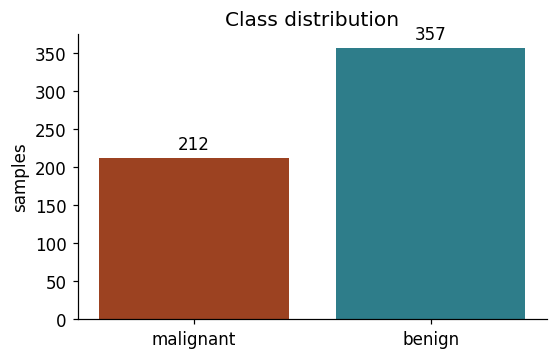

predicting 'benign' for everyone would be right 62.7% of the time


In [3]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
counts = np.bincount(y)
bars = ax.bar(class_names, counts, color=["#9C4221", "#2E7D8A"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_ylabel("samples")
ax.set_title("Class distribution")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"predicting 'benign' for everyone would be right {counts[1] / counts.sum():.1%} of the time")

## 4. Split before you do anything else

Here is the first rule that separates a valid experiment from a worthless one.

We hold out a **test set** now, before scaling, before selecting features, before
looking at correlations with the target. Everything we learn from here on is learnt
from the training set alone.

Why so strict? Because the test set exists to answer one question: *how will this
model behave on data it has never seen?* The moment any information from those rows
influences a decision — even something as innocent as computing a mean for scaling —
the test set stops being unseen, and the number it gives you is optimistic. That is
**data leakage**, and it is the single most common reason a machine learning result
turns out to be worthless. We come back to it in lesson 5, and you will meet it
deliberately broken in notebook 03.

`stratify=y` keeps the class proportions identical in both parts, so the test set is
a fair miniature of the whole.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"train: {X_train.shape[0]} samples    test: {X_test.shape[0]} samples")
print(f"class balance preserved: train {np.bincount(y_train) / len(y_train)}")
print(f"                          test {np.bincount(y_test) / len(y_test)}")

train: 426 samples    test: 143 samples
class balance preserved: train [0.37323944 0.62676056]
                          test [0.37062937 0.62937063]


## 5. Establish a baseline

Never evaluate a model in a vacuum. A number like "96% accurate" means nothing until
you know what the trivial answer scores.

`DummyClassifier` with `strategy="most_frequent"` always predicts the majority class.
It is the dumbest possible model, and it is the bar to beat.

In [5]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)
print(f"baseline accuracy: {baseline_acc:.3f}")

baseline accuracy: 0.629


## 6. A first real model

A pipeline chains the preprocessing and the model into one object. This is not
tidiness for its own sake: `StandardScaler` learns a mean and a standard deviation,
and inside a pipeline it learns them **from the training data only**, every time the
pipeline is fitted. Write the two steps separately and sooner or later you will scale
using statistics computed over the whole dataset — leakage, silently.

Logistic regression is a linear model for classification. We meet it properly in
lesson 4; today treat it as a black box that outputs a probability.

In [6]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)
model.fit(X_train, y_train)

model_acc = model.score(X_test, y_test)
print(f"baseline accuracy: {baseline_acc:.3f}")
print(f"model accuracy:    {model_acc:.3f}")
print(f"improvement:       {model_acc - baseline_acc:+.3f}")

baseline accuracy: 0.629
model accuracy:    0.986
improvement:       +0.357


## 7. Accuracy is not the answer

98.6% accuracy looks like a finished job. It is not, and seeing why is the most
important thing in this notebook.

Accuracy collapses every kind of mistake into one number. Our two mistakes are not
comparable: a missed malignant tumour is a different category of harm from a false
alarm. To see them separately we need the **confusion matrix**.

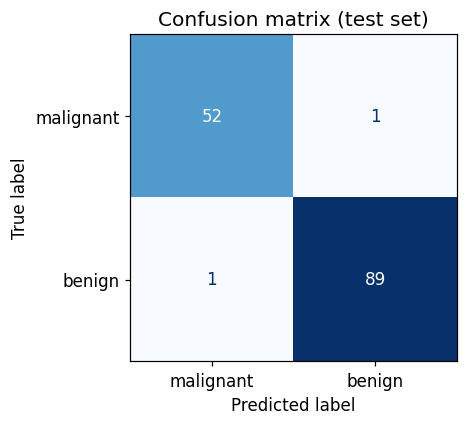

In [7]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=class_names,
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Confusion matrix (test set)")
fig.tight_layout()
fig.savefig(FIGURES / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

false_negatives = int(((y_test == 0) & (y_pred == 1)).sum())
false_positives = int(((y_test == 1) & (y_pred == 0)).sum())
print(f"malignant tumours called benign (the dangerous error): {false_negatives}")
print(f"benign tumours called malignant (the costly-but-safe error): {false_positives}")

              precision    recall  f1-score   support

   malignant      0.981     0.981     0.981        53
      benign      0.989     0.989     0.989        90

    accuracy                          0.986       143
   macro avg      0.985     0.985     0.985       143
weighted avg      0.986     0.986     0.986       143

malignant tumours called benign (the dangerous error): 1
benign tumours called malignant (the costly-but-safe error): 1


Read the report by column, not as a single score.

One malignant tumour was called benign. As a fraction that is 1 in 143 and vanishes into the accuracy figure; as a consequence it is a person sent home who should not have been. This is the gap between a metric and what the metric stands for.

**Recall** for the malignant class is the fraction of malignant tumours the model
actually caught. That is the number a clinician cares about, because its complement is
the patients sent home wrongly. **Precision** for that class is how often a malignancy
alert is correct — it governs how many unnecessary biopsies follow.

The two trade off against each other. Push recall towards 1.0 by flagging anything
suspicious and precision falls; demand high precision and you start missing cases. No
single number resolves that trade-off, because the resolution is not a mathematical
question. It is a question about consequences, and it belongs to the people who bear
them. We build the tools for this in lesson 4.

### The threshold nobody chose

Every number in the report above was computed at one threshold: call a tumour
malignant when the model gives that outcome a probability of at least **0.5**.
Nothing about the problem chose 0.5. It is a default.

Below, every one of the 143 test tumours is a dot, placed by the probability the
model assigned to *malignant*. The vertical line is the default threshold, and
moving it left or right is the whole of the trade-off: everything to the right of
the line is flagged, everything to the left is sent home.


 threshold   missed   false alarms   recall   precision
      0.10        0             11    1.000       0.828
      0.30        1              6    0.981       0.897
      0.50        1              1    0.981       0.981
      0.70        3              0    0.943       1.000
      0.90        7              0    0.868       1.000


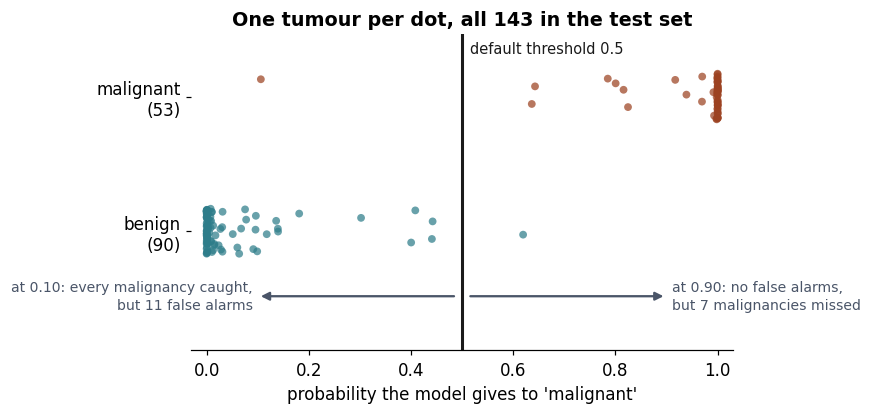

In [9]:
# decision scores, not predictions: predict_proba column 0 is class 0, which
# for this dataset is `malignant`. That is the axis the threshold slides along.
p_malignant = model.predict_proba(X_test)[:, 0]
is_malignant = (y_test == 0).to_numpy()

# What each threshold would actually cost, in tumours rather than in metrics.
print(f"{'threshold':>10}  {'missed':>7}  {'false alarms':>13}  {'recall':>7}  {'precision':>10}")
for t in (0.10, 0.30, 0.50, 0.70, 0.90):
    flagged = p_malignant >= t
    tp = int((flagged & is_malignant).sum())
    fp = int((flagged & ~is_malignant).sum())
    fn = int((~flagged & is_malignant).sum())
    print(f"{t:>10.2f}  {fn:>7d}  {fp:>13d}  "
          f"{tp / is_malignant.sum():>7.3f}  {tp / max(tp + fp, 1):>10.3f}")

TEAL, RUST, INK, SLATE = "#2E7D8A", "#9C4221", "#1A1A1A", "#4A5568"
jitter = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7.8, 3.9))
for values, row, colour in [(p_malignant[is_malignant], 1.0, RUST),
                            (p_malignant[~is_malignant], 0.0, TEAL)]:
    ax.scatter(values, row + jitter.uniform(-0.17, 0.17, values.size),
               s=26, color=colour, alpha=.72, edgecolor="none")

ax.axvline(0.5, lw=2.0, color=INK)
ax.text(0.515, 1.32, "default threshold 0.5", fontsize=9.6, color=INK)

ax.annotate("", xy=(0.10, -0.48), xytext=(0.49, -0.48),
            arrowprops=dict(arrowstyle="-|>", color=SLATE, lw=1.5))
ax.text(0.09, -0.48, "at 0.10: every malignancy caught,\nbut 11 false alarms",
        ha="right", va="center", fontsize=9.2, color=SLATE, linespacing=1.3)
ax.annotate("", xy=(0.90, -0.48), xytext=(0.51, -0.48),
            arrowprops=dict(arrowstyle="-|>", color=SLATE, lw=1.5))
ax.text(0.91, -0.48, "at 0.90: no false alarms,\nbut 7 malignancies missed",
        va="center", fontsize=9.2, color=SLATE, linespacing=1.3)

ax.set_yticks([0, 1])
ax.set_yticklabels([f"benign\n({(~is_malignant).sum()})",
                    f"malignant\n({is_malignant.sum()})"])
ax.set_ylim(-0.88, 1.46)
ax.set_xlim(-0.03, 1.03)
ax.set_xlabel("probability the model gives to 'malignant'")
ax.set_title("One tumour per dot, all 143 in the test set",
             fontsize=12.5, weight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "precision_recall_tradeoff.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()


## 8. What we did, and what we did not do

We went from a question to an evaluated model. The order was:

1. frame the problem, including what a harmful error would be
2. look at the data
3. **split, before anything is learnt**
4. baseline first
5. model inside a pipeline, so preprocessing is fitted on training data only
6. evaluate with a metric that matches the actual cost of being wrong

What we deliberately skipped: tuning, comparing model families, understanding which
features carry the signal, checking stability across different splits. Every one of
those is a lesson later in the course.

And note what we never did: look at the test set while making a decision. That
discipline is the reason the 98.6% is worth anything at all.

> **Try this:** change `RANDOM_STATE` to a few other values and rerun. How much does
> the test accuracy move? A number that swings by several points across splits is not
> one you should report to three decimal places — and lesson 5 gives you the tool for
> saying so honestly.

## Summary

- Framing comes before modelling: what is predicted, from what, and what makes an
  error harmful.
- Split the data before anything is learnt from it, or the evaluation is optimistic.
- A baseline turns a bare score into a meaningful comparison.
- Pipelines keep preprocessing honest by fitting it on training data only.
- Accuracy hides the structure of the mistakes; the confusion matrix shows it, and
  which error matters is a question about consequences, not about mathematics.